In [1]:
import numpy as np

#概率分布
probs = np.array([0.5,0.05,0.1,0.3,0.05])
words = ["I", "am", "learning", "LLM", "<eos>"]

#设置Top-K中的K
K = 3

# 获取概率最高的K个词汇的索引
# [-K:] 的意思就是 “从倒数第 K 个元素开始，一直取到数组结束”。
top_indices = np.argsort(probs)[-K:]

#保留K个词汇的索引
top_k_probs = np.zeros_like(probs)
top_k_probs[top_indices] = probs[top_indices]

# 归一化保留的 K 个词汇的概率
top_k_probs = top_k_probs / np.sum(top_k_probs)

# 打印 Top-K 的采样结果
print("Top-K 采样选择的词汇和对应的概率：")
for i in top_indices:
    print(f"{words[i]}: {top_k_probs[i]:.2f}")

Top-K 采样选择的词汇和对应的概率：
learning: 0.11
LLM: 0.33
I: 0.56


In [2]:
# 概率分布
probs = np.array([0.5, 0.05, 0.1, 0.3, 0.05])
words = ["I", "am", "learning", "LLM", "<eos>"]

# 设置top-p
P = 0.7

# 对概率进行排序
sorted_indices = np.argsort(probs)[::-1] # 从大到小排序
sorted_probs = probs[sorted_indices]

# 计算累积概率
# [0.1, 0.2, 0.3, 0.4] => [0.1, 0.3, 0.6, 1.0]
cumulative_probs = np.cumsum(sorted_probs)

# 找到累积概率大于等于P的索引
cutoff_index = np.where(cumulative_probs >= P)[0][0]

# 保留这些累积概率达到 P 得词汇及其概率
top_p_probs = np.zeros_like(probs)
top_p_probs[sorted_indices[:cutoff_index + 1]] = sorted_probs[:cutoff_index + 1]

# 归一化保留的 Top-P 词汇的概率
top_p_probs = top_p_probs / np.sum(top_p_probs)

# 打印 Top-P 的采样结果
print("Top-P 采样选择的词汇和对应的概率：")
for i in np.where(top_p_probs > 0)[0]:
    print(f"{words[i]}: {top_p_probs[i]:.2f}")

Top-P 采样选择的词汇和对应的概率：
I: 0.62
LLM: 0.37



 ----Temperature = 0.5 ----
I: 0.70
am: 0.01
learning: 0.03
LLM: 0.25
<eos>: 0.01

 ----Temperature = 1.0 ----
I: 0.50
am: 0.05
learning: 0.10
LLM: 0.30
<eos>: 0.05

 ----Temperature = 2.0 ----
I: 0.35
am: 0.11
learning: 0.16
LLM: 0.27
<eos>: 0.11


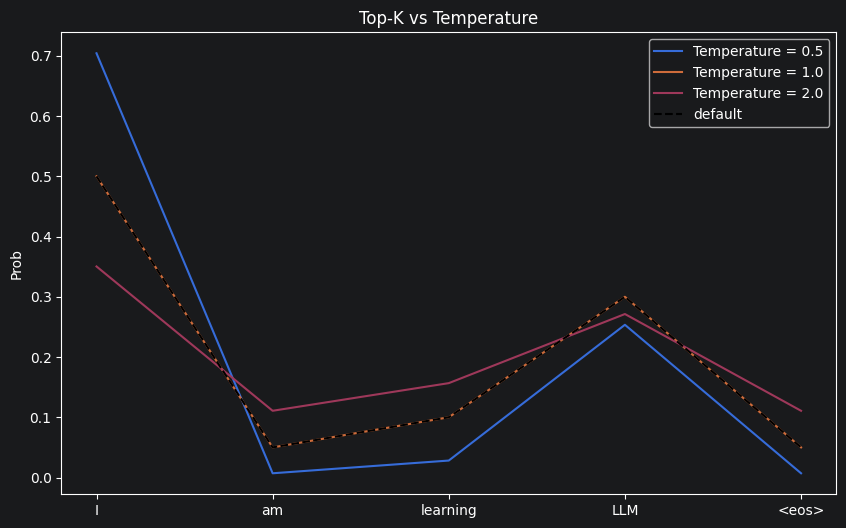

In [3]:
import matplotlib.pyplot as plt

# 概率分布
probs = np.array([0.5, 0.05, 0.1, 0.3, 0.05])
words = ["I", "am", "learning", "LLM", "<eos>"]

# 设置不同的temperatures
# p^(1/temperature)
temperatures = [0.5, 1.0, 2.0]


# 创建一个图表
plt.figure(figsize=(10, 6))

# 遍历不同的温度
for temp in temperatures:
    # 使用temperature调整概率分布
    adjusted_prob = probs ** (1.0 / temp)
    adjusted_prob = adjusted_prob / np.sum(adjusted_prob)

    # 打印调整后的 temperature 概率分布
    print(f"\n ----Temperature = {temp} ----")
    for i, prob in enumerate(adjusted_prob):
        print(f"{words[i]}: {prob:.2f}")

    plt.plot(words, adjusted_prob, label=f"Temperature = {temp}")

# 绘制原始概率分布的对比
plt.plot(words, probs, label="default", linestyle='--', color="black")

# 添加图表信息
plt.ylabel("Prob")
plt.title("Top-K vs Temperature")
plt.legend()

plt.show()

In [4]:
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# 指定模型
model_name = "distilgpt2"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 加载分词器和模型
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# 讲模型copy到GPU上
model.to(torch.device("cuda"))

# 输入文本
input_text = "I have a dream, and I"

# 编码输入文本
inputs = tokenizer.encode(input_text, return_tensors='pt').to(device)
attention_mask = torch.ones_like(inputs).to(device)

# 设置TOP-K, TOP-P和温度系数
top_k = 50
top_p = 0.5
temperature = 0.001


# 生成文本，利用top-k, top-p和文本来控制采样
with torch.no_grad():
    outputs = model.generate(
        inputs,
        attention_mask=attention_mask,
        max_length=50,
        do_sample=True,
        top_k=top_k,
        top_p=top_p,
        temperature=temperature,
        no_repeat_ngram_size=2,
        pad_token_id=tokenizer.eos_token_id
    )

# 解码生成的文本
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("结合TOP-K 和 TOP-P采样生成的文本：")
print(generated_text)


结合TOP-K 和 TOP-P采样生成的文本：
I have a dream, and I'm going to be a part of it. I want to do it for the first time.

"I'm not going anywhere. It's not my dream. But I am going. And I hope that


In [5]:
# 生成文本，只利用top-p来控制采样
with torch.no_grad():
    outputs = model.generate(
        inputs,
        attention_mask=attention_mask,
        max_length=50,
        do_sample=True,
        top_k=0,
        top_p=0.9,
        temperature=temperature,
        no_repeat_ngram_size=2,
        pad_token_id=tokenizer.eos_token_id
    )

# 解码生成的文本
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("结合TOP-K 和 TOP-P采样生成的文本：")
print(generated_text)

结合TOP-K 和 TOP-P采样生成的文本：
I have a dream, and I'm going to be a part of it. I want to do it for the first time.

"I'm not going anywhere. It's not my dream. But I am going. And I hope that
